# **Experimento Algirtmos Detección y Corección**

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 100)

PAGE_ORDER = ["13", "13-14", "13-15", "13-16", "13-17", "13-18"]
PROBABILITY_ORDER = [0.0, 0.01, 0.1, 1.0]

possible_results_directories = [
    Path("results"),
    Path("cliente-python/experiments/results"),
]

results_directory = next(
    (directory for directory in possible_results_directories if directory.exists()),
    None,
)

if results_directory is None:
    raise FileNotFoundError("No se encontró la carpeta experiments/results.")

crc32_results = pd.read_csv(results_directory / "gear_fourth_crc32_results.csv")
hamming_results = pd.read_csv(results_directory / "gear_fourth_hamming_results.csv")

for results in (crc32_results, hamming_results):
    results["pages"] = pd.Categorical(
        results["pages"],
        categories=PAGE_ORDER,
        ordered=True,
    )

## **Validación de los datos**

In [2]:
validation_table = pd.DataFrame(
    {
        "algoritmo": ["CRC-32", "Hamming"],
        "ensayos": [len(crc32_results), len(hamming_results)],
        "tamaños_acumulados": [crc32_results["pages"].nunique(), hamming_results["pages"].nunique()],
        "probabilidades": [
            crc32_results["configured_error_probability_percent"].nunique(),
            hamming_results["configured_error_probability_percent"].nunique(),
        ],
        "repeticiones_por_combinación": [
            crc32_results.groupby(["pages", "configured_error_probability_percent"], observed=True).size().min(),
            hamming_results.groupby(["pages", "configured_error_probability_percent"], observed=True).size().min(),
        ],
    }
)
validation_table

,algoritmo,ensayos,tamaños_acumulados,probabilidades,repeticiones_por_combinación
0,CRC-32,2400,6,4,100
1,Hamming,2400,6,4,100


In [3]:
def build_time_summary(results):
    summary = (
        results.groupby(
            ["pages", "configured_error_probability_percent"],
            observed=True,
        )["round_trip_milliseconds"]
        .agg(
            ensayos="count",
            media_ms="mean",
            mediana_ms="median",
            desviación_estándar_ms="std",
            mínimo_ms="min",
            máximo_ms="max",
        )
        .reset_index()
    )
    return summary.round(4)


def build_status_summary(results):
    summary = (
        results.groupby(
            ["configured_error_probability_percent", "status"],
            observed=True,
        )
        .size()
        .rename("cantidad")
        .reset_index()
    )
    totals = summary.groupby("configured_error_probability_percent")["cantidad"].transform("sum")
    summary["porcentaje"] = (summary["cantidad"] / totals * 100).round(2)
    return summary


def build_overhead_summary(results):
    columns = [
        "pages",
        "payload_bits",
        "serialized_data_bits",
        "codeword_bits",
        "redundancy_bits",
        "overhead_percentage",
    ]
    summary = (
        results[columns]
        .groupby("pages", observed=True)
        .first()
        .reset_index()
    )
    summary["overhead_percentage"] = summary["overhead_percentage"].round(2)
    return summary


def plot_median_time(results, algorithm_name):
    grouped_results = (
        results.groupby(
            ["payload_bits", "configured_error_probability_percent"],
            observed=True,
        )["round_trip_milliseconds"]
        .median()
        .reset_index()
    )

    figure, axis = plt.subplots(figsize=(9, 5))
    for probability in PROBABILITY_ORDER:
        probability_results = grouped_results[
            grouped_results["configured_error_probability_percent"] == probability
        ]
        axis.plot(
            probability_results["payload_bits"],
            probability_results["round_trip_milliseconds"],
            marker="o",
            label=f"{probability:g}%",
        )

    axis.set_title(f"{algorithm_name}: mediana del tiempo de transmisión")
    axis.set_xlabel("Tamaño del contenido original (bits)")
    axis.set_ylabel("Tiempo de ida y vuelta (ms)")
    axis.legend(title="Probabilidad configurada")
    plt.tight_layout()
    plt.show()


def plot_effectiveness(results, algorithm_name, successful_status, effectiveness_name):
    altered_results = results[
        (results["actual_flips"] > 0)
        & (results["configured_error_probability_percent"] > 0)
    ].copy()
    altered_results["successful_result"] = altered_results["status"] == successful_status

    effectiveness = (
        altered_results.groupby(
            ["payload_bits", "configured_error_probability_percent"],
            observed=True,
        )["successful_result"]
        .mean()
        .mul(100)
        .reset_index(name="effectiveness_percentage")
    )

    figure, axis = plt.subplots(figsize=(9, 5))
    for probability in PROBABILITY_ORDER[1:]:
        probability_results = effectiveness[
            effectiveness["configured_error_probability_percent"] == probability
        ]
        axis.plot(
            probability_results["payload_bits"],
            probability_results["effectiveness_percentage"],
            marker="o",
            label=f"{probability:g}%",
        )

    axis.set_title(f"{algorithm_name}: {effectiveness_name}")
    axis.set_xlabel("Tamaño del contenido original (bits)")
    axis.set_ylabel("Porcentaje de ensayos alterados (%)")
    axis.set_ylim(0, 105)
    axis.legend(title="Probabilidad configurada")
    plt.tight_layout()
    plt.show()


def plot_overhead(results, algorithm_name):
    overhead = build_overhead_summary(results)

    figure, axis = plt.subplots(figsize=(9, 5))
    axis.plot(
        overhead["payload_bits"],
        overhead["overhead_percentage"],
        marker="o",
        color="#7c3aed",
    )
    axis.set_title(f"{algorithm_name}: sobrecarga por redundancia")
    axis.set_xlabel("Tamaño del contenido original (bits)")
    axis.set_ylabel("Sobrecarga (%)")
    plt.tight_layout()
    plt.show()

## **CRC-32**

### **Estadísticas del tiempo de transmisión**

In [4]:
build_time_summary(crc32_results)

,pages,configured_error_probability_percent,ensayos,media_ms,mediana_ms,desviación_estándar_ms,mínimo_ms,máximo_ms
0,13,0.00,100,4.3701,4.3550,0.0846,4.2248,4.7137
1,13,0.01,100,4.3719,4.3559,0.0946,4.2408,4.7488
2,13,0.10,100,4.4983,4.4945,0.0735,4.2758,4.7704
3,13,1.00,100,4.4817,4.4753,0.0582,4.3514,4.6372
4,13-14,0.00,100,9.3788,9.3703,0.1272,9.1280,9.9045
5,13-14,0.01,100,9.3619,9.3138,0.2236,9.0432,10.3076
6,13-14,0.10,100,9.3178,9.3003,0.1049,9.1386,9.6924
7,13-14,1.00,100,9.4330,9.3837,0.2283,9.0838,10.3821
8,13-15,0.00,100,12.2578,11.1891,5.8344,10.8303,65.5686
9,13-15,0.01,100,10.9122,10.8618,0.2906,10.4323,11.6792


### **Distribución de resultados**

In [5]:
build_status_summary(crc32_results)

,configured_error_probability_percent,status,cantidad,porcentaje
0,0.00,CLEAN,600,100.0
1,0.01,CLEAN,195,32.5
2,0.01,CRC_DETECTED,405,67.5
3,0.10,CRC_DETECTED,600,100.0
4,1.00,CRC_DETECTED,600,100.0


### **Redundancia y sobrecarga**

In [6]:
build_overhead_summary(crc32_results)

,pages,payload_bits,serialized_data_bits,codeword_bits,redundancy_bits,overhead_percentage
0,13,4344,4496,4528,32,0.71
1,13-14,9288,9440,9472,32,0.34
2,13-15,10912,11064,11096,32,0.29
3,13-16,17648,17800,17832,32,0.18
4,13-17,23208,23360,23392,32,0.14
5,13-18,25472,25624,25656,32,0.12


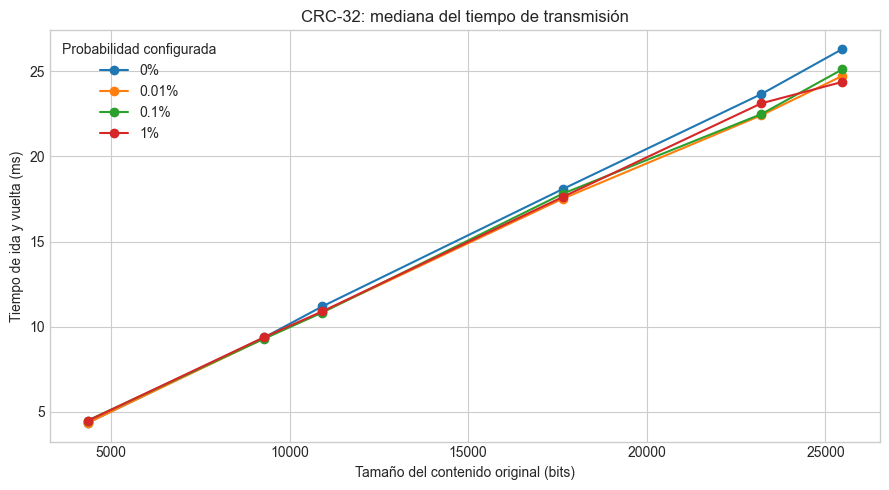

In [7]:
plot_median_time(crc32_results, "CRC-32")

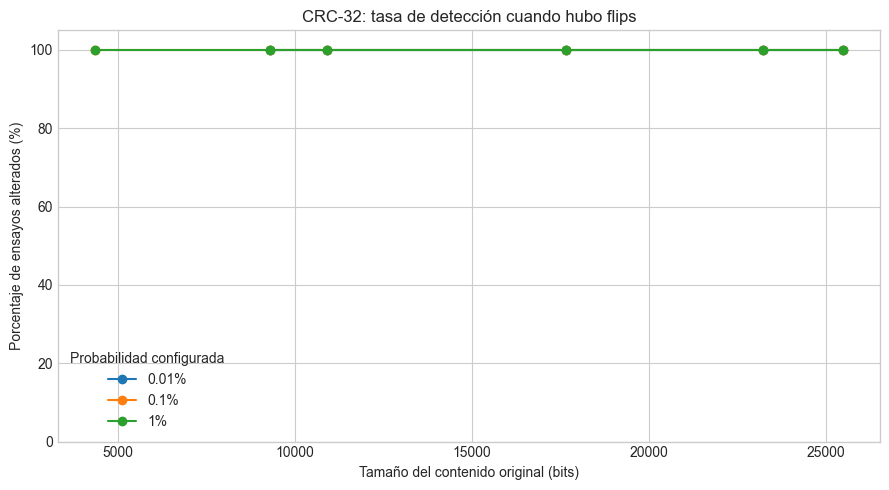

In [8]:
plot_effectiveness(
    crc32_results,
    algorithm_name="CRC-32",
    successful_status="CRC_DETECTED",
    effectiveness_name="tasa de detección cuando hubo flips",
)

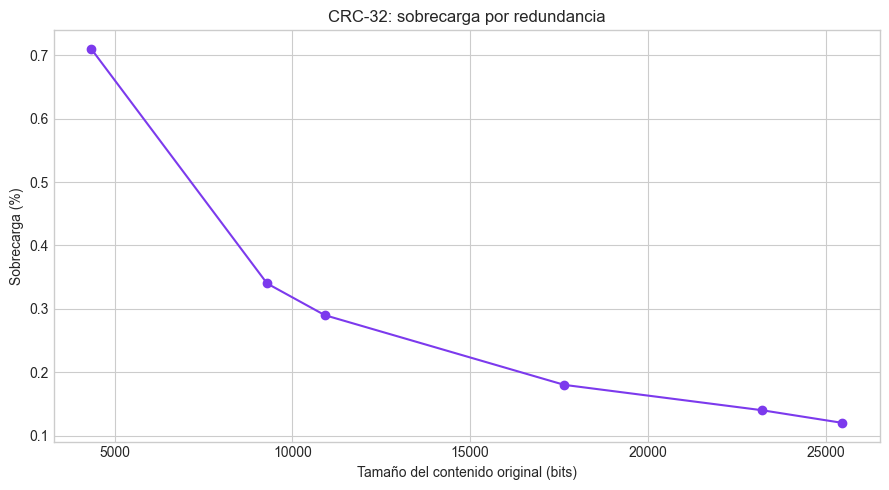

In [9]:
plot_overhead(crc32_results, "CRC-32")

## **Hamming**

### **Estadísticas del tiempo de transmisión**

In [10]:
build_time_summary(hamming_results)

,pages,configured_error_probability_percent,ensayos,media_ms,mediana_ms,desviación_estándar_ms,mínimo_ms,máximo_ms
0,13,0.00,100,2.6835,2.6081,0.1871,2.4512,3.2688
1,13,0.01,100,2.6082,2.5980,0.0740,2.4360,3.0049
2,13,0.10,100,2.5955,2.5965,0.0429,2.4135,2.7532
3,13,1.00,100,2.6761,2.6076,0.3336,2.4344,4.9852
4,13-14,0.00,100,5.2623,5.2823,0.0822,4.9838,5.4103
5,13-14,0.01,100,5.2812,5.2752,0.0955,4.9800,5.5686
6,13-14,0.10,100,5.2238,5.2200,0.0769,5.0480,5.7050
7,13-14,1.00,100,5.1640,5.1674,0.0521,5.0178,5.2919
8,13-15,0.00,100,6.5777,6.5723,0.0675,6.4301,6.8220
9,13-15,0.01,100,6.4897,6.4674,0.0803,6.3805,6.9799


### **Distribución de resultados**

In [11]:
build_status_summary(hamming_results)

,configured_error_probability_percent,status,cantidad,porcentaje
0,0.00,CLEAN,600,100.00
1,0.01,CLEAN,100,16.67
2,0.01,HAMMING_CORRECTED,497,82.83
3,0.01,HAMMING_RECOVERY_FAILED,3,0.50
4,0.10,HAMMING_CORRECTED,529,88.17
5,0.10,HAMMING_RECOVERY_FAILED,71,11.83
6,1.00,HAMMING_CORRECTED,5,0.83
7,1.00,HAMMING_RECOVERY_FAILED,595,99.17


### **Redundancia y sobrecarga**

In [13]:
build_overhead_summary(hamming_results)

,pages,payload_bits,serialized_data_bits,codeword_bits,redundancy_bits,overhead_percentage
0,13,4344,4496,6744,2248,50.0
1,13-14,9288,9440,14160,4720,50.0
2,13-15,10912,11064,16596,5532,50.0
3,13-16,17648,17800,26700,8900,50.0
4,13-17,23208,23360,35040,11680,50.0
5,13-18,25472,25624,38436,12812,50.0


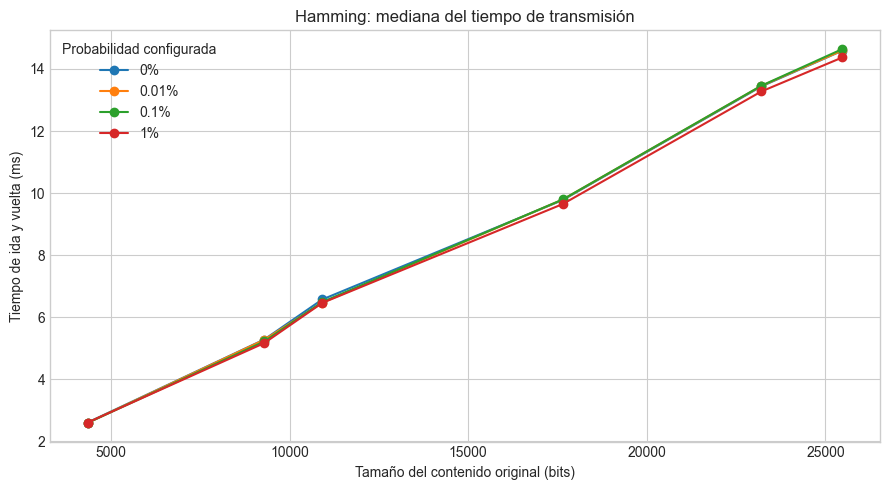

In [14]:
plot_median_time(hamming_results, "Hamming")

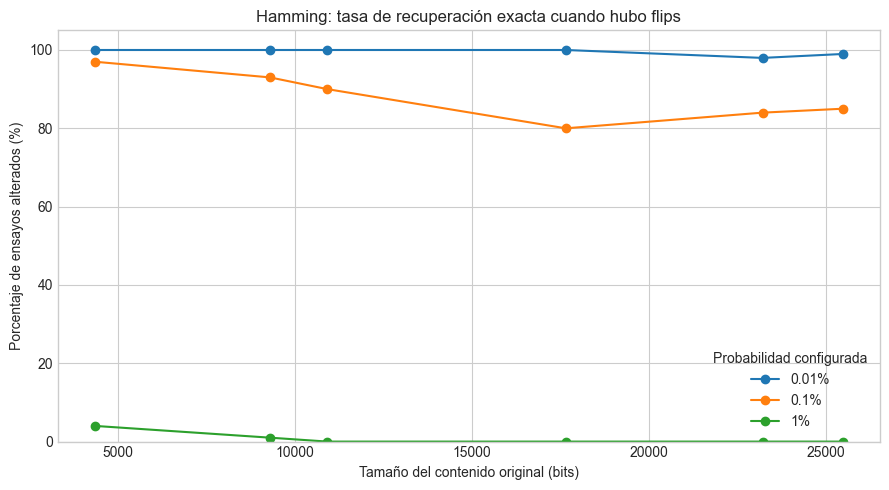

In [15]:
plot_effectiveness(
    hamming_results,
    algorithm_name="Hamming",
    successful_status="HAMMING_CORRECTED",
    effectiveness_name="tasa de recuperación exacta cuando hubo flips",
)

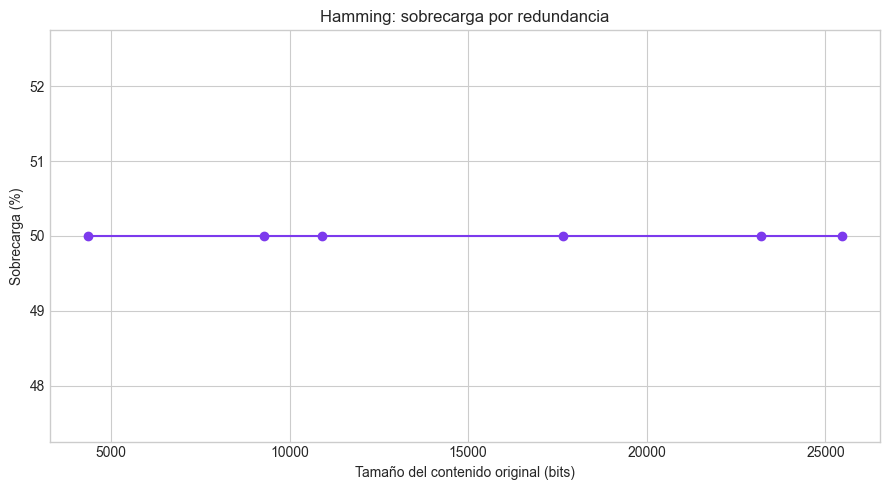

In [16]:
plot_overhead(hamming_results, "Hamming")